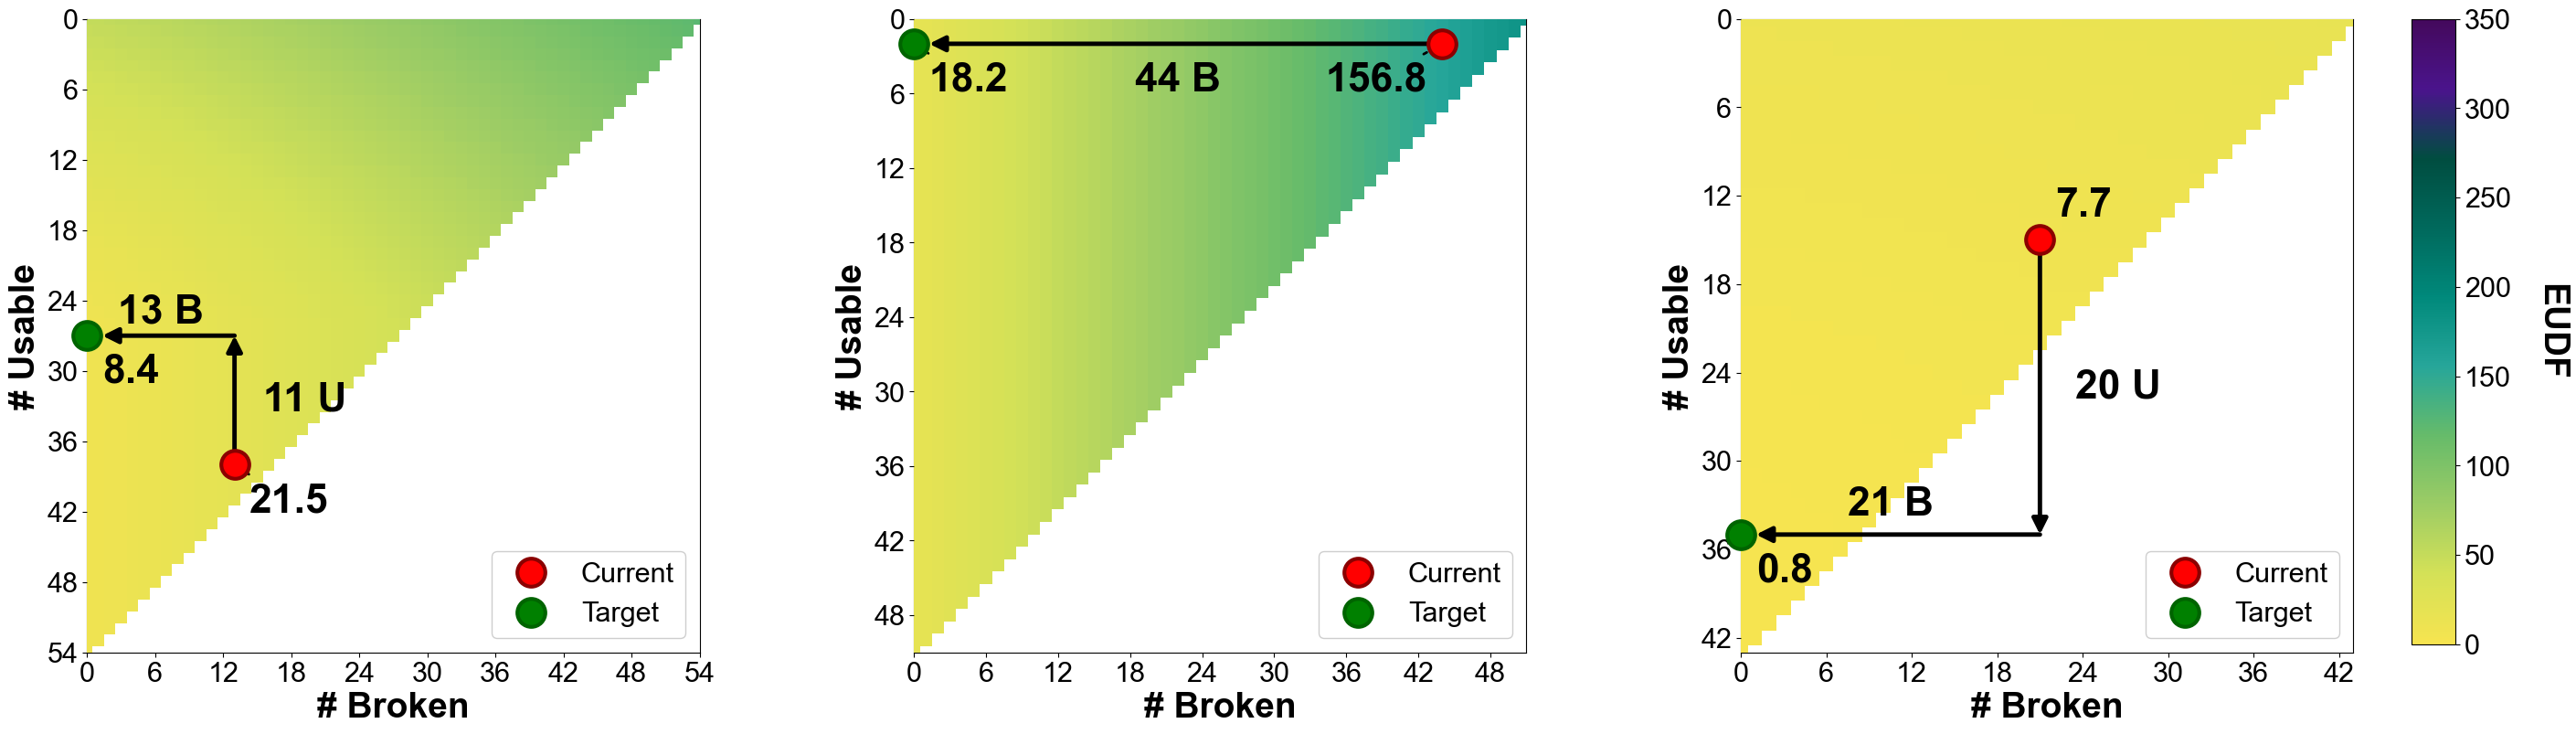

Plots saved successfully!

Station 1 (Moderate sensitivity):
  Target EUDF: 8.43, Current EUDF: 21.46
  Change: 13.03 for 13 broken + 11 usable bikes

Station 2 (HIGH sensitivity):
  Target EUDF: 18.25, Current EUDF: 156.83
  Change: 138.58 for 44 broken bikes

Station 3 (LOW sensitivity):
  Target EUDF: 0.83, Current EUDF: 7.70
  Change: 6.87 for 21 broken + 20 usable bikes


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import rcParams

# Set font globally - MUCH larger for poster readability
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 28

def eudf_model(usable, broken, optimal_usable, alpha, beta, gamma, delta, base_eudf=0):
    """
    Model EUDF (Expected User Dissatisfaction Function)
    """
    shortage = np.maximum(0, optimal_usable - usable)
    shortage_penalty = alpha * np.power(shortage, beta)
    broken_penalty = gamma * np.power(broken, delta)
    return base_eudf + shortage_penalty + broken_penalty

# Create figure with 3 subplots - WIDER for poster
fig, axes = plt.subplots(1, 3, figsize=(32, 9))
plt.subplots_adjust(right=0.90, wspace=0.35)

# Colormap matching reference: yellow (#f6e450) to purple (#44095c)
colors_list = [
    '#f6e450',  # bright yellow (low EUDF)
    '#d4e157',  # yellow-green
    '#9ccc65',  # light green
    '#66bb6a',  # green
    '#26a69a',  # teal
    '#00897b',  # darker teal
    '#00695c',  # dark teal
    '#004d40',  # very dark teal
    '#4a148c',  # purple
    '#44095c',  # dark purple (high EUDF)
]
cmap = mcolors.LinearSegmentedColormap.from_list('custom_yp', colors_list, N=256)

# Callout styling - MUCH larger fonts
callout_fs = 32
callout_line = dict(arrowstyle='-', color='black', lw=2, shrinkA=8)

# ============ Station 1 (Left plot) - Moderate sensitivity ============
# This station shows moderate sensitivity - color changes gradually with bike operations
max_bikes_1 = 55
capacity_1 = 54

usable_range_1 = np.arange(0, max_bikes_1)
broken_range_1 = np.arange(0, max_bikes_1)
U1, B1 = np.meshgrid(usable_range_1, broken_range_1, indexing='ij')

# Moderate sensitivity parameters - tuned to get Current EUDF ~23.33
optimal_usable_1 = 27
alpha1, beta1, gamma1, delta1 = 0.5, 1.35, 0.6, 1.2
EUDF_1 = eudf_model(U1, B1, optimal_usable_1, alpha1, beta1, gamma1, delta1, base_eudf=8.43)

mask_1 = (U1 + B1) > capacity_1
EUDF_1_masked = np.ma.masked_where(mask_1, EUDF_1)

ax1 = axes[0]
vmin1, vmax1 = 0, 350
im1 = ax1.pcolormesh(broken_range_1, usable_range_1, EUDF_1_masked, cmap=cmap, vmin=vmin1, vmax=vmax1, shading='auto')

# Target: 0 broken bikes, optimal usable; Current: some broken, different usable
target_1 = (0, 27)  # (broken, usable) - target has 0 broken
current_1 = (13, 38)

eudf_target_1 = eudf_model(target_1[1], target_1[0], optimal_usable_1, alpha1, beta1, gamma1, delta1, 8.43)
eudf_current_1 = eudf_model(current_1[1], current_1[0], optimal_usable_1, alpha1, beta1, gamma1, delta1, 8.43)

# L-shaped arrows: current -> turning point -> target (THICKER arrows for visibility)
# Arrow 1: from current to turning point (vertical)
ax1.annotate('', xy=(current_1[0], target_1[1]), xytext=(current_1[0], current_1[1]),
             arrowprops=dict(arrowstyle='-|>', color='black', lw=3.5, mutation_scale=25, shrinkA=12, shrinkB=0), zorder=4)
# Arrow 2: from turning point to target (horizontal)
ax1.annotate('', xy=(target_1[0], target_1[1]), xytext=(current_1[0], target_1[1]),
             arrowprops=dict(arrowstyle='-|>', color='black', lw=3.5, mutation_scale=25, shrinkA=0, shrinkB=12), zorder=4)

# Plot dots on top (clip_on=False so edge dots are fully visible) - LARGER markers
ax1.plot(current_1[0], current_1[1], 'ro', markersize=22, markeredgecolor='darkred', markeredgewidth=3,
         label='Current', zorder=30, clip_on=False)
ax1.plot(target_1[0], target_1[1], 'go', markersize=22, markeredgecolor='darkgreen', markeredgewidth=3,
         label='Target', zorder=30, clip_on=False)

# Labels - SHORT format: "13 B" instead of "13 broken" - CLOSER to arrows
mid_x_1 = (current_1[0] + target_1[0]) / 2
mid_y_1 = (current_1[1] + target_1[1]) / 2

ax1.text(mid_x_1, target_1[1] - 2, '13 B',
         ha='center', va='center', fontsize=callout_fs, fontweight='bold', zorder=25)

ax1.text(current_1[0] + 2.5, mid_y_1, '11 U',
         ha='left', va='center', fontsize=callout_fs, fontweight='bold', zorder=25)

# EUDF values (shorter leader lines - closer to dots)
ax1.annotate(f'{eudf_target_1:.1f}',
             xy=target_1, xycoords='data',
             xytext=(12, -14), textcoords='offset points',
             ha='left', va='top', fontsize=callout_fs, fontweight='bold',
             arrowprops=dict(**callout_line, shrinkB=14),
             annotation_clip=False, zorder=25)

ax1.annotate(f'{eudf_current_1:.1f}',
             xy=current_1, xycoords='data',
             xytext=(12, -14), textcoords='offset points',
             ha='left', va='top', fontsize=callout_fs, fontweight='bold',
             arrowprops=dict(**callout_line, shrinkB=14),
             annotation_clip=False, zorder=25)

ax1.set_xlabel('# Broken', fontsize=28, fontweight='bold')
ax1.set_ylabel('# Usable', fontsize=28, fontweight='bold')
ax1.set_xlim(0, 54)
ax1.set_ylim(54, 0)
ax1.set_xticks(np.arange(0, 55, 6))
ax1.set_yticks(np.arange(0, 55, 6))
ax1.tick_params(axis='both', labelsize=22)
ax1.legend(loc='lower right', fontsize=22, framealpha=0.95)

# ============ Station 2 (Middle plot) - HIGH sensitivity ============
# This station is VERY sensitive - even small changes cause dramatic color shifts
max_bikes_2 = 52
capacity_2 = 51

usable_range_2 = np.arange(0, max_bikes_2)
broken_range_2 = np.arange(0, max_bikes_2)
U2, B2 = np.meshgrid(usable_range_2, broken_range_2, indexing='ij')

# High sensitivity parameters - tuned to get Target ~18.25, Current ~109.06
optimal_usable_2 = 0  # Target at usable=0 is already optimal
alpha2, beta2, gamma2, delta2 = 3.0, 1.2, 2.0, 1.12
EUDF_2 = eudf_model(U2, B2, optimal_usable_2, alpha2, beta2, gamma2, delta2, base_eudf=18.25)

mask_2 = (U2 + B2) > capacity_2
EUDF_2_masked = np.ma.masked_where(mask_2, EUDF_2)

ax2 = axes[1]
vmin2, vmax2 = 0, 350
im2 = ax2.pcolormesh(broken_range_2, usable_range_2, EUDF_2_masked, cmap=cmap, vmin=vmin2, vmax=vmax2, shading='auto')

# Target has 0 broken bikes; Current has many broken bikes (usable ~2 to avoid axis overlap)
current_2 = (44, 2)  # (broken, usable) - many broken, few usable
target_2 = (0, 2)    # (broken, usable) - target has 0 broken

eudf_current_2 = eudf_model(current_2[1], current_2[0], optimal_usable_2, alpha2, beta2, gamma2, delta2, 18.25)
eudf_target_2 = eudf_model(target_2[1], target_2[0], optimal_usable_2, alpha2, beta2, gamma2, delta2, 18.25)

# Single-headed arrow: current -> target (THICKER arrow for visibility)
ax2.annotate('', xy=(target_2[0], target_2[1]), xytext=(current_2[0], current_2[1]),
             arrowprops=dict(arrowstyle='-|>', color='black', lw=3.5, mutation_scale=25, shrinkA=12, shrinkB=12), zorder=4)

# Plot dots on top (clip_on=False so edge dots are fully visible) - LARGER markers
ax2.plot(current_2[0], current_2[1], 'ro', markersize=22, markeredgecolor='darkred', markeredgewidth=3,
         label='Current', zorder=30, clip_on=False)
ax2.plot(target_2[0], target_2[1], 'go', markersize=22, markeredgecolor='darkgreen', markeredgewidth=3,
         label='Target', zorder=30, clip_on=False)

# Labels - SHORT format - CLOSER to arrow
mid_x_2 = (current_2[0] + target_2[0]) / 2

ax2.text(mid_x_2, target_2[1] + 3, '44 B',
         ha='center', va='center', fontsize=callout_fs, fontweight='bold', zorder=25)

# EUDF values (shorter leader lines - closer to dots)
ax2.annotate(f'{eudf_target_2:.1f}',
             xy=target_2, xycoords='data',
             xytext=(12, -14), textcoords='offset points',
             ha='left', va='top', fontsize=callout_fs, fontweight='bold',
             arrowprops=dict(**callout_line, shrinkB=14),
             annotation_clip=False, zorder=25)

ax2.annotate(f'{eudf_current_2:.1f}',
             xy=current_2, xycoords='data',
             xytext=(-12, -14), textcoords='offset points',
             ha='right', va='top', fontsize=callout_fs, fontweight='bold',
             arrowprops=dict(**callout_line, shrinkB=14),
             annotation_clip=False, zorder=25)

ax2.set_xlabel('# Broken', fontsize=28, fontweight='bold')
ax2.set_ylabel('# Usable', fontsize=28, fontweight='bold')
ax2.set_xlim(0, 51)
ax2.set_ylim(51, 0)
ax2.set_xticks(np.arange(0, 52, 6))
ax2.set_yticks(np.arange(0, 52, 6))
ax2.tick_params(axis='both', labelsize=22)
ax2.legend(loc='lower right', fontsize=22, framealpha=0.95)

# ============ Station 3 (Right plot) - LOW sensitivity ============
# This station is NOT sensitive - color barely changes even with many bike operations
max_bikes_3 = 44
capacity_3 = 43

usable_range_3 = np.arange(0, max_bikes_3)
broken_range_3 = np.arange(0, max_bikes_3)
U3, B3 = np.meshgrid(usable_range_3, broken_range_3, indexing='ij')

# Low sensitivity - tuned to get Current ~8.79 (minimal change even with 21 broken + 20 usable)
optimal_usable_3 = 35
alpha3, beta3, gamma3, delta3 = 0.06, 1.45, 0.05, 1.25
EUDF_3 = eudf_model(U3, B3, optimal_usable_3, alpha3, beta3, gamma3, delta3, base_eudf=0.83)

mask_3 = (U3 + B3) > capacity_3
EUDF_3_masked = np.ma.masked_where(mask_3, EUDF_3)

ax3 = axes[2]
vmin3, vmax3 = 0, 350
im3 = ax3.pcolormesh(broken_range_3, usable_range_3, EUDF_3_masked, cmap=cmap, vmin=vmin3, vmax=vmax3, shading='auto')

# Target has 0 broken bikes; Current has many broken, fewer usable
current_3 = (21, 15)  # (broken, usable)
target_3 = (0, 35)    # (broken, usable) - target has 0 broken

eudf_current_3 = eudf_model(current_3[1], current_3[0], optimal_usable_3, alpha3, beta3, gamma3, delta3, 0.83)
eudf_target_3 = eudf_model(target_3[1], target_3[0], optimal_usable_3, alpha3, beta3, gamma3, delta3, 0.83)

# L-shaped arrows: current -> turning point -> target (THICKER arrows for visibility)
# Arrow 1: from current to turning point (vertical)
ax3.annotate('', xy=(current_3[0], target_3[1]), xytext=(current_3[0], current_3[1]),
             arrowprops=dict(arrowstyle='-|>', color='black', lw=3.5, mutation_scale=25, shrinkA=12, shrinkB=0), zorder=4)
# Arrow 2: from turning point to target (horizontal)
ax3.annotate('', xy=(target_3[0], target_3[1]), xytext=(current_3[0], target_3[1]),
             arrowprops=dict(arrowstyle='-|>', color='black', lw=3.5, mutation_scale=25, shrinkA=0, shrinkB=12), zorder=4)

# Plot dots on top (clip_on=False so edge dots are fully visible) - LARGER markers
ax3.plot(current_3[0], current_3[1], 'ro', markersize=22, markeredgecolor='darkred', markeredgewidth=3,
         label='Current', zorder=30, clip_on=False)
ax3.plot(target_3[0], target_3[1], 'go', markersize=22, markeredgecolor='darkgreen', markeredgewidth=3,
         label='Target', zorder=30, clip_on=False)

# Labels - SHORT format - CLOSER to arrows
mid_x_3 = (current_3[0] + target_3[0]) / 2
mid_y_3 = (current_3[1] + target_3[1]) / 2

ax3.text(mid_x_3, target_3[1] - 2, '21 B',
         ha='center', va='center', fontsize=callout_fs, fontweight='bold', zorder=25)

ax3.text(current_3[0] + 2.5, mid_y_3, '20 U',
         ha='left', va='center', fontsize=callout_fs, fontweight='bold', zorder=25)

# EUDF values (shorter leader lines - closer to dots)
ax3.annotate(f'{eudf_target_3:.1f}',
             xy=target_3, xycoords='data',
             xytext=(12, -14), textcoords='offset points',
             ha='left', va='top', fontsize=callout_fs, fontweight='bold',
             arrowprops=dict(**callout_line, shrinkB=14),
             annotation_clip=False, zorder=25)

ax3.annotate(f'{eudf_current_3:.1f}',
             xy=current_3, xycoords='data',
             xytext=(12, 12), textcoords='offset points',
             ha='left', va='bottom', fontsize=callout_fs, fontweight='bold',
             arrowprops=dict(**callout_line, shrinkB=14),
             annotation_clip=False, zorder=25)

ax3.set_xlabel('# Broken', fontsize=28, fontweight='bold')
ax3.set_ylabel('# Usable', fontsize=28, fontweight='bold')
ax3.set_xlim(0, 43)
ax3.set_ylim(43, 0)
ax3.set_xticks(np.arange(0, 44, 6))
ax3.set_yticks(np.arange(0, 44, 6))
ax3.tick_params(axis='both', labelsize=22)
ax3.legend(loc='lower right', fontsize=22, framealpha=0.95)

# Ensure axes frames (spines) stay behind markers/callouts (edge dots remain fully visible)
for ax in axes:
    for spine in ax.spines.values():
        spine.set_zorder(0)

# Add colorbar (shared) with LARGER fonts
cbar_ax = fig.add_axes([0.92, 0.12, 0.015, 0.76])
cbar = fig.colorbar(im2, cax=cbar_ax)
cbar.set_label('EUDF', fontsize=28, fontweight='bold', labelpad=18, rotation=270, va='bottom')
cbar.ax.tick_params(labelsize=22)

# Save the figure
plt.savefig('/Users/hurunqiu/trb_poster/figures/heatmap-of-eudf.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('/Users/hurunqiu/trb_poster/figures/heatmap-of-eudf.pdf', bbox_inches='tight', facecolor='white')
plt.show()

print("Plots saved successfully!")
print(f"\nStation 1 (Moderate sensitivity):")
print(f"  Target EUDF: {eudf_target_1:.2f}, Current EUDF: {eudf_current_1:.2f}")
print(f"  Change: {eudf_current_1 - eudf_target_1:.2f} for 13 broken + 11 usable bikes")
print(f"\nStation 2 (HIGH sensitivity):")
print(f"  Target EUDF: {eudf_target_2:.2f}, Current EUDF: {eudf_current_2:.2f}")
print(f"  Change: {eudf_current_2 - eudf_target_2:.2f} for 44 broken bikes")
print(f"\nStation 3 (LOW sensitivity):")
print(f"  Target EUDF: {eudf_target_3:.2f}, Current EUDF: {eudf_current_3:.2f}")
print(f"  Change: {eudf_current_3 - eudf_target_3:.2f} for 21 broken + 20 usable bikes")